In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "outputs" / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

train_cleaned_path = PROCESSED_DIR / "train_cleaned.csv"
test_cleaned_path = PROCESSED_DIR / "test_cleaned.csv"
target_path = PROCESSED_DIR / "target.csv"

In [3]:
train_cleaned = pd.read_csv(train_cleaned_path)
test_cleaned = pd.read_csv(test_cleaned_path)
target = pd.read_csv(target_path)

y = target["SalePrice"]
y_log = target["SalePrice_Log"]

print("Train cleaned shape:", train_cleaned.shape)
print("Test cleaned shape:", test_cleaned.shape)
print("Target shape:", y.shape)
print("Log target shape:", y_log.shape)

Train cleaned shape: (1460, 91)
Test cleaned shape: (1459, 91)
Target shape: (1460,)
Log target shape: (1460,)


In [4]:
train_ids = train_cleaned["Id"]
test_ids = test_cleaned["Id"]

X = train_cleaned.drop(columns=["Id"])
X_test = test_cleaned.drop(columns=["Id"])

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (1460, 90)
X_test shape: (1459, 90)


In [5]:
outlier_ids = [524, 1299]

outlier_mask = train_ids.isin(outlier_ids)

X = X.loc[~outlier_mask].copy()
y_log_model = y_log.loc[~outlier_mask].copy()

print("X shape after removing outliers:", X.shape)
print("y_log shape after removing outliers:", y_log_model.shape)

X shape after removing outliers: (1458, 90)
y_log shape after removing outliers: (1458,)


In [6]:
combined = pd.concat([X, X_test], axis=0)

combined_encoded = pd.get_dummies(combined, drop_first=False)

X_encoded = combined_encoded.iloc[:len(X), :].copy()
X_test_encoded = combined_encoded.iloc[len(X):, :].copy()

print("X encoded shape:", X_encoded.shape)
print("X test encoded shape:", X_test_encoded.shape)

X encoded shape: (1458, 297)
X test encoded shape: (1459, 297)


In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y_log_model,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (1166, 297)
X_valid shape: (292, 297)
y_train shape: (1166,)
y_valid shape: (292,)


In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [9]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_valid)

linear_rmse = rmse(y_valid, linear_preds)

print("Linear Regression RMSE:", linear_rmse)

Linear Regression RMSE: 0.13668243555453516


In [10]:
ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train, y_train)

ridge_preds = ridge_model.predict(X_valid)

ridge_rmse = rmse(y_valid, ridge_preds)

print("Ridge RMSE:", ridge_rmse)

Ridge RMSE: 0.12295922922887918


In [11]:
lasso_model = Lasso(alpha=0.0005, max_iter=10000)

lasso_model.fit(X_train, y_train)

lasso_preds = lasso_model.predict(X_valid)

lasso_rmse = rmse(y_valid, lasso_preds)

print("Lasso RMSE:", lasso_rmse)

Lasso RMSE: 0.11748319423367334


In [12]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

rf_preds = random_forest_model.predict(X_valid)

rf_rmse = rmse(y_valid, rf_preds)

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 0.14519964429425022


In [13]:
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

gb_preds = gradient_boosting_model.predict(X_valid)

gb_rmse = rmse(y_valid, gb_preds)

print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting RMSE: 0.12069983599810337


In [14]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Validation RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        gb_rmse
    ]
})

model_results = model_results.sort_values(by="Validation RMSE")

model_results

,Model,Validation RMSE
2,Lasso,0.117483
4,Gradient Boosting,0.120700
1,Ridge,0.122959
0,Linear Regression,0.136682
3,Random Forest,0.145200


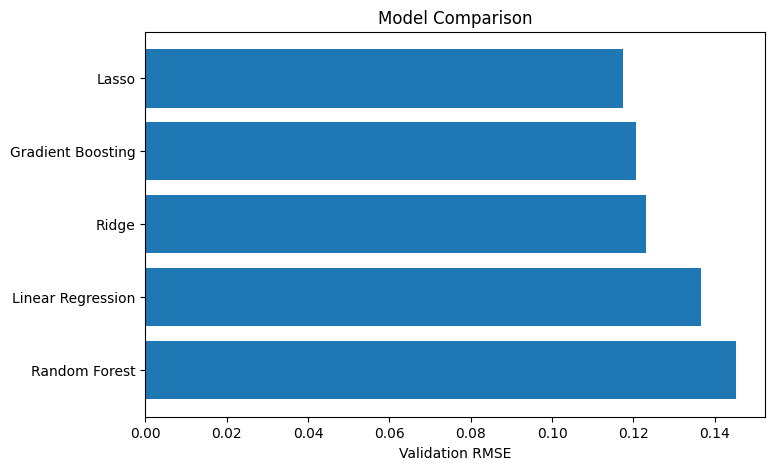

In [15]:
plt.figure(figsize=(8, 5))
plt.barh(model_results["Model"][::-1], model_results["Validation RMSE"][::-1])
plt.xlabel("Validation RMSE")
plt.title("Model Comparison")
plt.show()

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [17]:
def cross_validate_model(model, X, y, cv=5):
    kfold = KFold(
        n_splits=cv,
        shuffle=True,
        random_state=42
    )
    
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=kfold,
        n_jobs=-1
    )
    
    rmse_scores = np.sqrt(-scores)
    
    return rmse_scores

In [18]:
cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005, max_iter=20000))
    ]),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [19]:
cv_results = []

for model_name, model in cv_models.items():
    scores = cross_validate_model(model, X_encoded, y_log_model, cv=5)
    
    cv_results.append({
        "Model": model_name,
        "CV RMSE Mean": scores.mean(),
        "CV RMSE Std": scores.std()
    })
    
    print(model_name)
    print("RMSE scores:", scores)
    print("Mean RMSE:", scores.mean())
    print("Std RMSE:", scores.std())
    print("-" * 40)

Linear Regression
RMSE scores: [0.13728958 0.14380025 0.1250339  0.15639934 0.10709235]
Mean RMSE: 0.1339230831587628
Std RMSE: 0.01681059008792226
----------------------------------------
Ridge
RMSE scores: [0.1302584  0.14160624 0.12242775 0.1379665  0.10617571]
Mean RMSE: 0.1276869188699033
Std RMSE: 0.012620782139848347
----------------------------------------
Lasso
RMSE scores: [0.12582915 0.13613094 0.12012087 0.13211984 0.10435834]
Mean RMSE: 0.12371182727826333
Std RMSE: 0.011107334070998091
----------------------------------------
Random Forest
RMSE scores: [0.14548195 0.12705192 0.14178391 0.13685392 0.13144928]
Mean RMSE: 0.13652419615290262
Std RMSE: 0.006685707550849978
----------------------------------------
Gradient Boosting
RMSE scores: [0.12069984 0.11624321 0.12254646 0.1328278  0.12312653]
Mean RMSE: 0.12308876637802521
Std RMSE: 0.0054353104817745565
----------------------------------------


In [20]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="CV RMSE Mean")

cv_results_df

,Model,CV RMSE Mean,CV RMSE Std
4,Gradient Boosting,0.123089,0.005435
2,Lasso,0.123712,0.011107
1,Ridge,0.127687,0.012621
0,Linear Regression,0.133923,0.016811
3,Random Forest,0.136524,0.006686


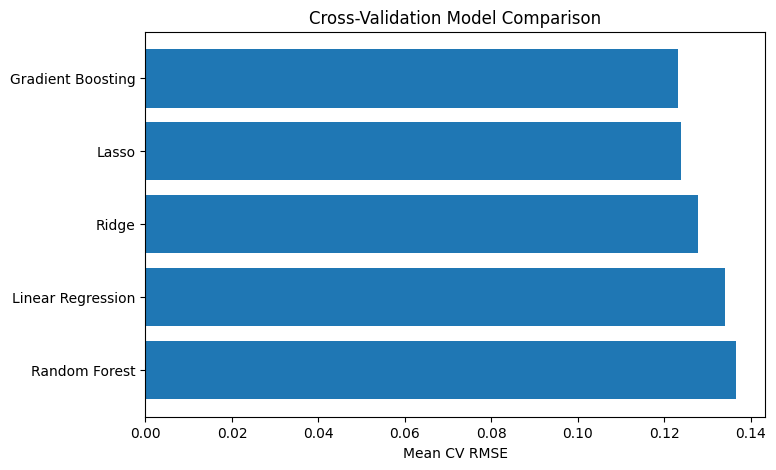

In [21]:
plt.figure(figsize=(8, 5))
plt.barh(cv_results_df["Model"][::-1], cv_results_df["CV RMSE Mean"][::-1])
plt.xlabel("Mean CV RMSE")
plt.title("Cross-Validation Model Comparison")
plt.show()

In [28]:
final_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_model.fit(X_encoded, y_log_model)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [29]:
test_log_predictions = final_model.predict(X_test_encoded)

test_predictions = np.expm1(test_log_predictions)

print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())

Minimum prediction: 38620.92081685478
Maximum prediction: 737605.8145256066


In [30]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

submission.head()

,Id,SalePrice
0,1461,124295.306832
1,1462,160934.554185
2,1463,182050.332294
3,1464,192586.325070
4,1465,191856.577635


In [32]:
submission_path = OUTPUT_DIR / "submission_gradient_boosting.csv"

submission.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)

Submission saved to: ../outputs/submission_gradient_boosting.csv


In [33]:
submission.sort_values(by="SalePrice", ascending=False).head(10)

,Id,SalePrice
1089,2550,737605.814526
1222,2683,580969.468002
203,1664,542044.760369
834,2295,529992.732351
803,2264,529861.582378
19,1480,524532.527902
514,1975,517451.553217
1168,2629,513445.270749
1167,2628,505571.753609
1229,2690,501640.944109


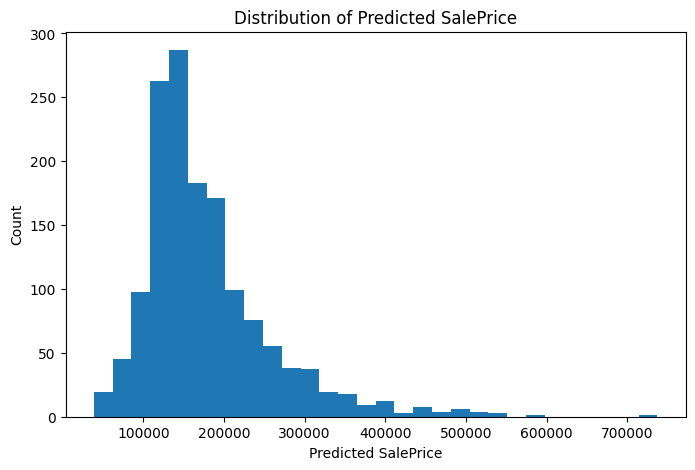

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(submission["SalePrice"], bins=30)
plt.xlabel("Predicted SalePrice")
plt.ylabel("Count")
plt.title("Distribution of Predicted SalePrice")
plt.show()

In [35]:
cv_results_path = OUTPUT_DIR / "model_cv_results.csv"

cv_results_df.to_csv(cv_results_path, index=False)

print("CV results saved to:", cv_results_path)

CV results saved to: ../outputs/model_cv_results.csv


## Modeling Summary

Bu aşamada temizlenmiş ve feature engineering uygulanmış veri seti kullanılarak farklı regression modelleri karşılaştırılmıştır.

İlk validation sonuçlarına göre en iyi performansı Lasso modeli göstermiştir.

Daha güvenilir değerlendirme için 5-fold cross-validation uygulanmıştır. Lineer modeller için `StandardScaler` kullanılmıştır. Çünkü lineer modeller değişken ölçeklerinden etkilenebilir.

Modelleme aşamasında kullanılan modeller:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Hedef değişken olarak `SalePrice` yerine log dönüşümü uygulanmış `SalePrice_Log` kullanılmıştır. Final tahminler `np.expm1()` ile tekrar orijinal fiyat ölçeğine dönüştürülmüştür.

Final submission dosyası `outputs/submission_lasso.csv` olarak kaydedilmiştir.

## Modeling Summary

In this stage, several regression models were trained and compared using the cleaned and feature-engineered dataset.

Based on the initial validation results, the Lasso model achieved the best performance.

To obtain a more reliable evaluation, 5-fold cross-validation was applied. `StandardScaler` was used for linear models because they are sensitive to feature scaling.

Models used in this stage:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The log-transformed target variable `SalePrice_Log` was used during training. Final predictions were transformed back to the original price scale using `np.expm1()`.

The final submission file was saved as `outputs/submission_lasso.csv`.

In [36]:
test_predictions_df = submission.rename(columns={
    "SalePrice": "PredictedSalePrice"
})

test_predictions_df.head()

,Id,PredictedSalePrice
0,1461,124295.306832
1,1462,160934.554185
2,1463,182050.332294
3,1464,192586.325070
4,1465,191856.577635


In [37]:
test_predictions_df.sort_values(
    by="PredictedSalePrice",
    ascending=False
).head(10)

,Id,PredictedSalePrice
1089,2550,737605.814526
1222,2683,580969.468002
203,1664,542044.760369
834,2295,529992.732351
803,2264,529861.582378
19,1480,524532.527902
514,1975,517451.553217
1168,2629,513445.270749
1167,2628,505571.753609
1229,2690,501640.944109


In [38]:
predictions_path = OUTPUT_DIR / "predictions_gradient_boosting.csv"

test_predictions_df.to_csv(predictions_path, index=False)

print("Predictions saved to:", predictions_path)

Predictions saved to: ../outputs/predictions_gradient_boosting.csv


In [39]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
36,TotalSF,0.362754
3,OverallQual,0.351730
37,TotalBathrooms,0.052662
4,OverallCond,0.016980
25,GarageCars,0.016304
6,YearRemodAdd,0.015064
2,LotArea,0.014307
15,GrLivArea,0.012714
39,HouseAge,0.011319
40,RemodAge,0.010764


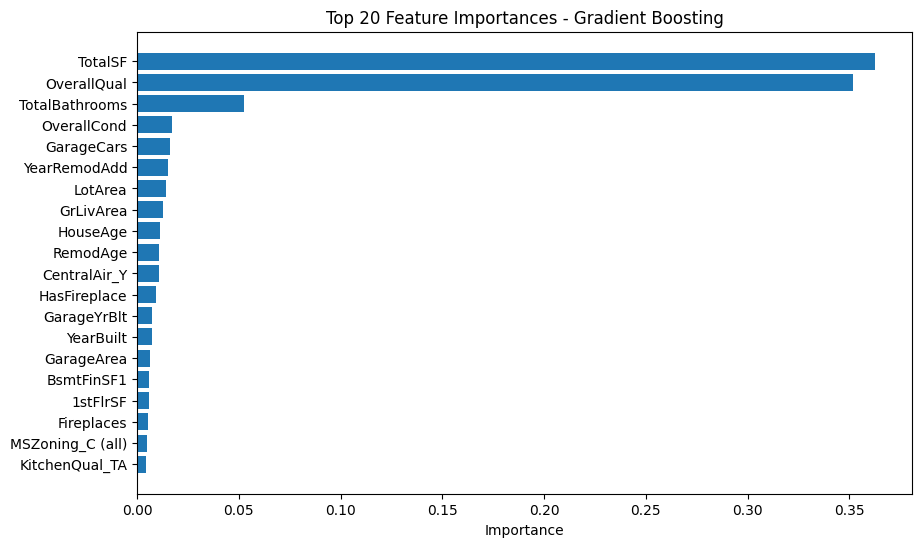

In [40]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - Gradient Boosting")
plt.show()

In [41]:
feature_importance_path = OUTPUT_DIR / "feature_importance_gradient_boosting.csv"

feature_importance.to_csv(feature_importance_path, index=False)

print("Feature importance saved to:", feature_importance_path)

Feature importance saved to: ../outputs/feature_importance_gradient_boosting.csv


## Final Model Selection

Cross-validation results showed that `GradientBoostingRegressor` achieved the best overall performance.

| Model | CV RMSE Mean | CV RMSE Std |
|---|---:|---:|
| Gradient Boosting | 0.123089 | 0.005435 |
| Lasso | 0.123712 | 0.011107 |
| Ridge | 0.127687 | 0.012621 |
| Linear Regression | 0.133923 | 0.016811 |
| Random Forest | 0.136524 | 0.006686 |

Although Lasso performed best on the initial validation split, Gradient Boosting achieved a slightly better mean RMSE and lower standard deviation during 5-fold cross-validation. Therefore, Gradient Boosting was selected as the final model.

The final model was trained using the cleaned and feature-engineered training data. Since the test dataset does not contain the target variable, predictions were generated for inference purposes only.

The following output files were saved:

- `outputs/predictions_gradient_boosting.csv`
- `outputs/model_cv_results.csv`
- `outputs/feature_importance_gradient_boosting.csv`

## Final Model Seçimi

Cross-validation sonuçlarına göre en iyi genel performansı `GradientBoostingRegressor` modeli göstermiştir.

| Model | CV RMSE Mean | CV RMSE Std |
|---|---:|---:|
| Gradient Boosting | 0.123089 | 0.005435 |
| Lasso | 0.123712 | 0.011107 |
| Ridge | 0.127687 | 0.012621 |
| Linear Regression | 0.133923 | 0.016811 |
| Random Forest | 0.136524 | 0.006686 |

İlk validation ayrımında Lasso modeli en iyi sonucu vermiş olsa da, 5-fold cross-validation sonucunda Gradient Boosting modeli daha düşük ortalama hata ve daha düşük standart sapma elde etmiştir. Bu nedenle final model olarak Gradient Boosting seçilmiştir.

Final model, temizlenmiş ve feature engineering uygulanmış eğitim verisiyle eğitilmiştir. Test veri setinde hedef değişken bulunmadığı için test seti üzerinde yalnızca tahmin üretimi yapılmıştır.

Aşağıdaki çıktı dosyaları kaydedilmiştir:

- `outputs/predictions_gradient_boosting.csv`
- `outputs/model_cv_results.csv`
- `outputs/feature_importance_gradient_boosting.csv`